In [ ]:
project_path = "/content/drive/MyDrive/nlp_classification"

In [ ]:
import sys

sys.path.append(project_path)

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

import json
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import (
    CountVectorizer,
    TfidfVectorizer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [ ]:
from core.utils import init_random_seed, divide_data
from core.nlp import tokenize_tiktoken, filter_tokens
from core.visualization import compare_metrics_heatmap

from core.baseline_training import train_evaluate_models_cv
from core.vectorization import NgramFeatureSelector

In [ ]:
SEED = 42

init_random_seed(SEED)

In [ ]:
def save_metrics_to_csv(metrics, metrics_file_name):
    metrics.to_dataframe().to_csv(
        f"{project_path}/{metrics_file_name}.csv", encoding="utf-8"
    )


def load_metrics_from_csv(metrics_file_name):
    df = pd.read_csv(f"{project_path}/{metrics_file_name}.csv", index_col=0)
    return df

## 1. Загрузка и препроцессинг данных

In [ ]:
df = pd.read_csv(f"{project_path}/ecommerceDataset.csv", names=["Category", "Text"])

In [ ]:
df_preprocessed = df.copy()

df_preprocessed = df_preprocessed.drop_duplicates().reset_index(drop=True)

df_preprocessed = df_preprocessed.dropna().reset_index(drop=True)

category_dict = {
    "Electronics": 0,
    "Household": 1,
    "Books": 2,
    "Clothing & Accessories": 3,
}

df_preprocessed = df_preprocessed.replace({"Category": category_dict})

df_preprocessed["Text"] = df_preprocessed["Text"].apply(tokenize_tiktoken)


/tmp/ipykernel_29713/14240627.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_preprocessed = df_preprocessed.replace({'Category': category_dict})


In [ ]:
# Разделяем данные на признаки (X) и целевую переменную (y)
X, y = divide_data(df_preprocessed, "Category")

## 2. Построение baseline

In [ ]:
device = "CPU"

models = [
    ("DummyClassifier", DummyClassifier(random_state=SEED, strategy="stratified")),
    (
        "LogisticRegression",
        LogisticRegression(random_state=SEED, max_iter=1000, solver="lbfgs"),
    ),
    ("DecisionTree", DecisionTreeClassifier(random_state=SEED, max_depth=4)),
    ("RandomForest", RandomForestClassifier(random_state=SEED, n_jobs=-1)),
    ("LGBM", LGBMClassifier(random_state=SEED, verbose=-1, device=device.lower())),
]

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
cv

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

### 2.1. CountVectorizer

#### 2.1.1 Без очистки токенов

In [ ]:
count_vectorizer_processor = Pipeline(
    [
        (
            "vectorizer",
            ColumnTransformer(
                [
                    (
                        "text_vectorizer",
                        CountVectorizer(
                            analyzer=lambda x: x, min_df=50, dtype=np.float32
                        ),
                        "Text",
                    )
                ],
                remainder="passthrough",
                verbose_feature_names_out=True,
            ),
        )
    ]
)

count_vectorizer_processor

Pipeline(steps=[('vectorizer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('text_vectorizer',
                                                  CountVectorizer(analyzer=<function <lambda> at 0x7f0afb217ba0>,
                                                                  dtype=<class 'numpy.float32'>,
                                                                  min_df=50),
                                                  'Text')]))])

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

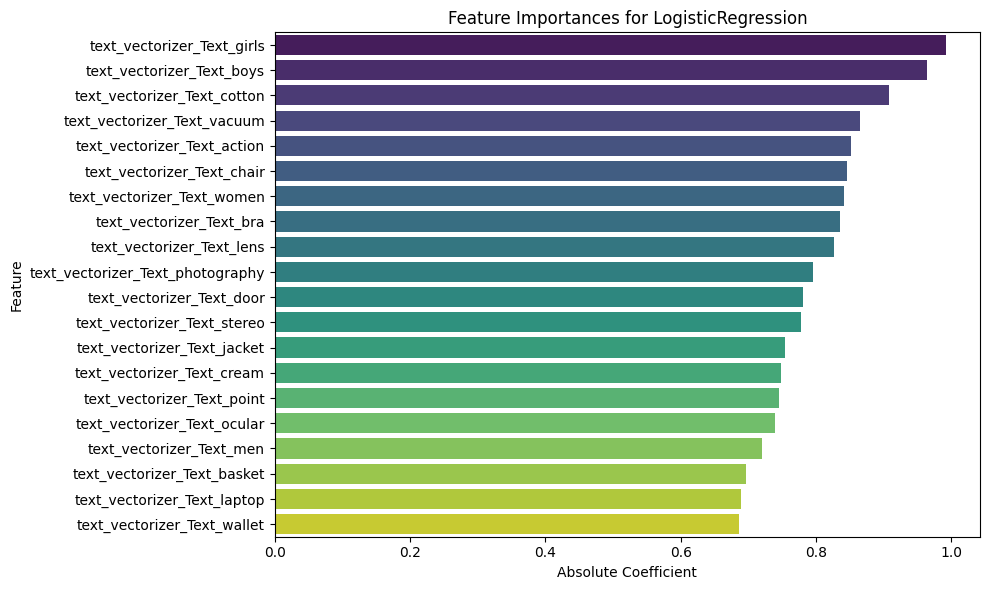

<Figure size 1500x600 with 0 Axes>

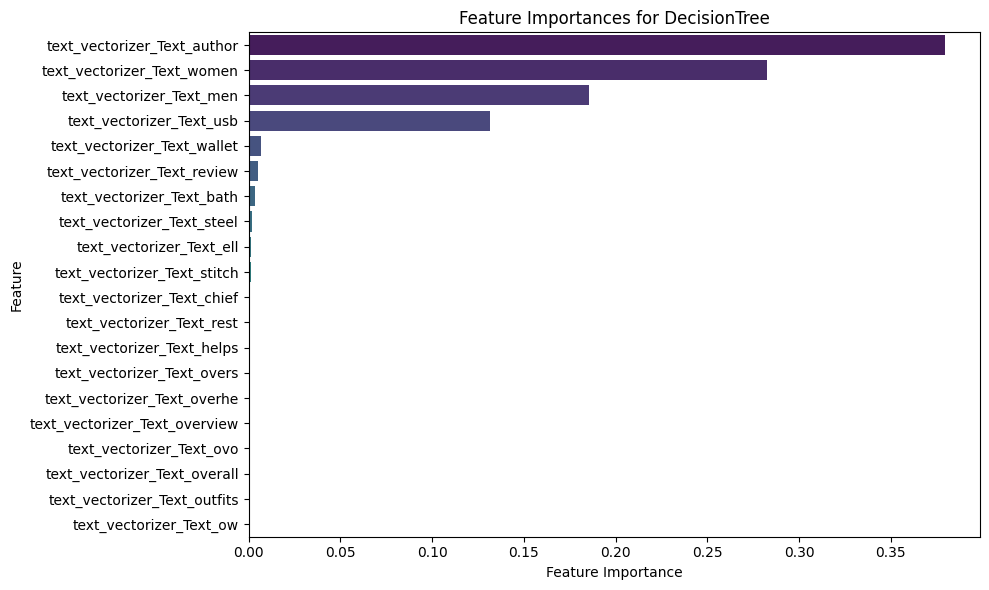

<Figure size 1500x600 with 0 Axes>

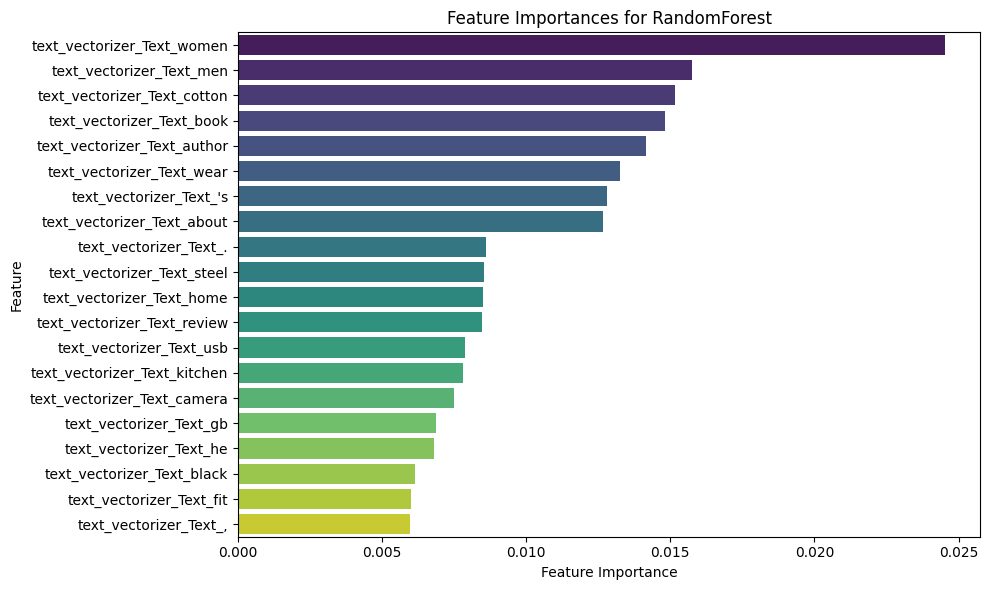

<Figure size 1500x600 with 0 Axes>

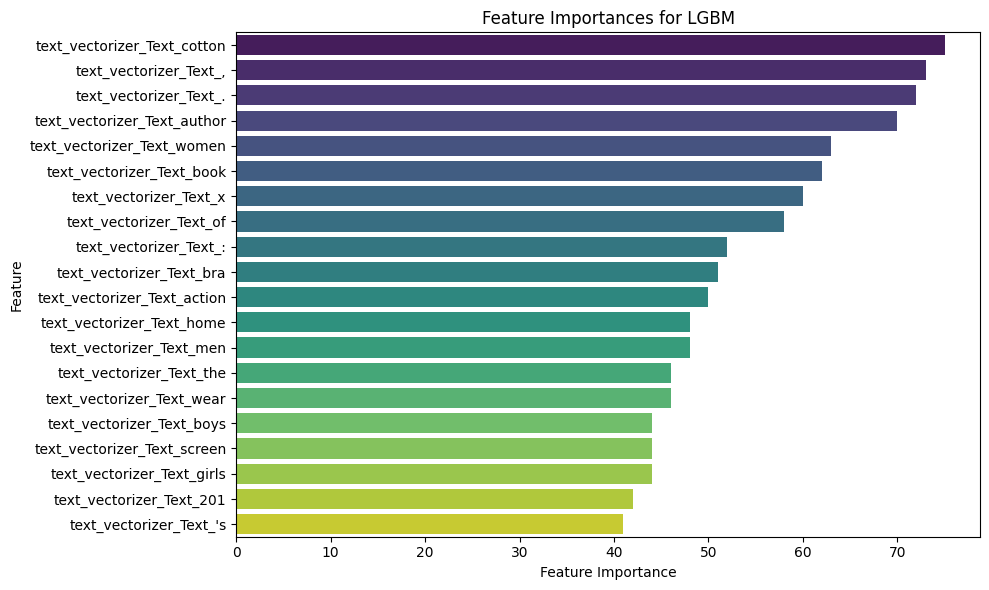

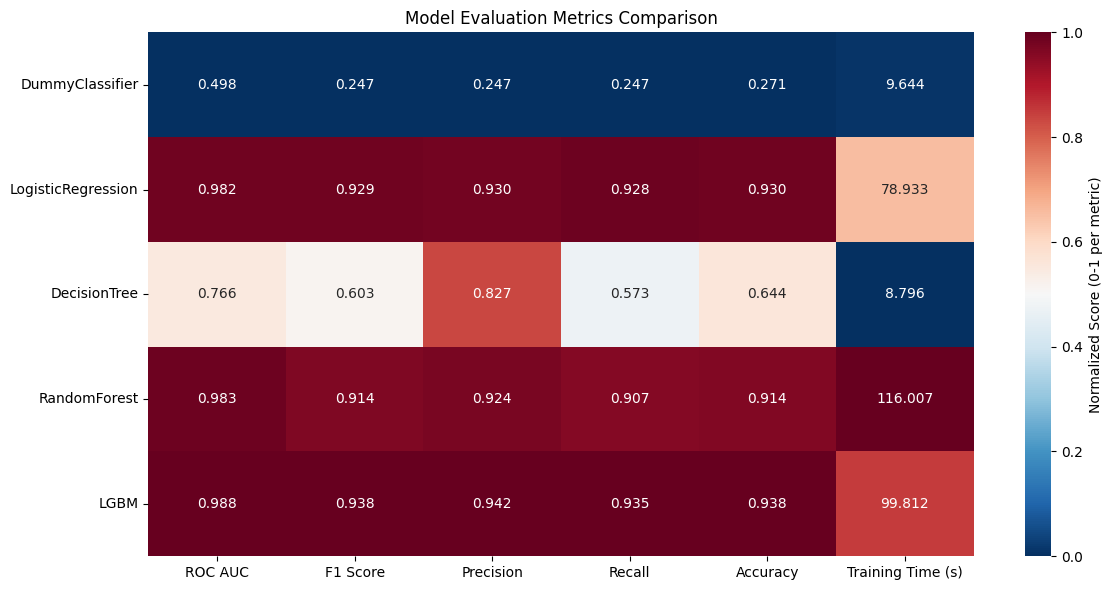

In [ ]:
count_vectorizer_metrics = train_evaluate_models_cv(
    models, X, y, count_vectorizer_processor, cv, SEED
)

У логистической регрессии, случайного леса и LGBM уже очень хорошие метрики. Из них быстрее всех обучилась логистическая регрессия.

Также можно заметить что LGBM посчитал токены пунктуации достаточно важными. Нужно проверить что будет с качеством предсказания после удаления пунктуации и стоп-слов.

In [ ]:
metrics_file_name = "count_vectorizer_metrics"

save_metrics_to_csv(count_vectorizer_metrics, metrics_file_name)
# count_vectorizer_metrics = load_metrics_from_csv(metrics_file_name)

#### 2.1.2 Удалим стоп-слова

In [ ]:
X_cleaned = X.copy()
X_cleaned["Text"] = X_cleaned["Text"].map(
    lambda tokens: filter_tokens(
        tokens,
        remove_stopwords=True,
        remove_punctuation_tokens=False,
        lowercase_for_counting=True,
    )
)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

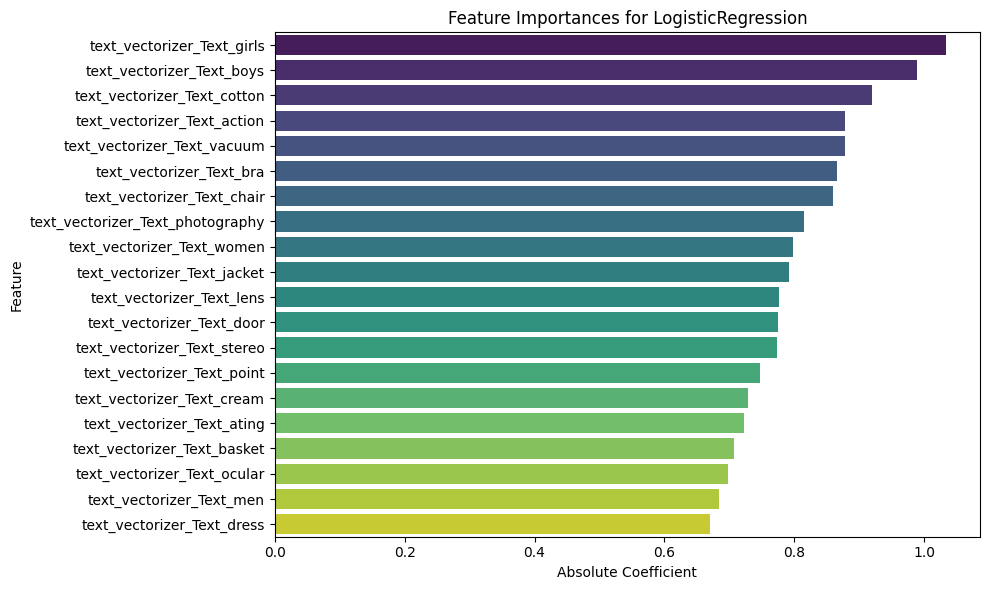

<Figure size 1500x600 with 0 Axes>

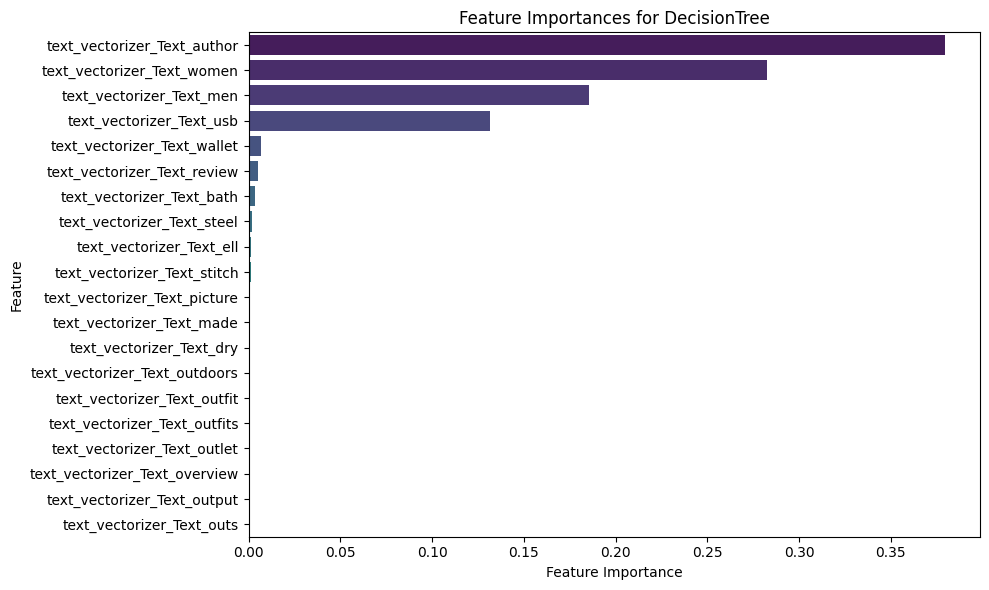

<Figure size 1500x600 with 0 Axes>

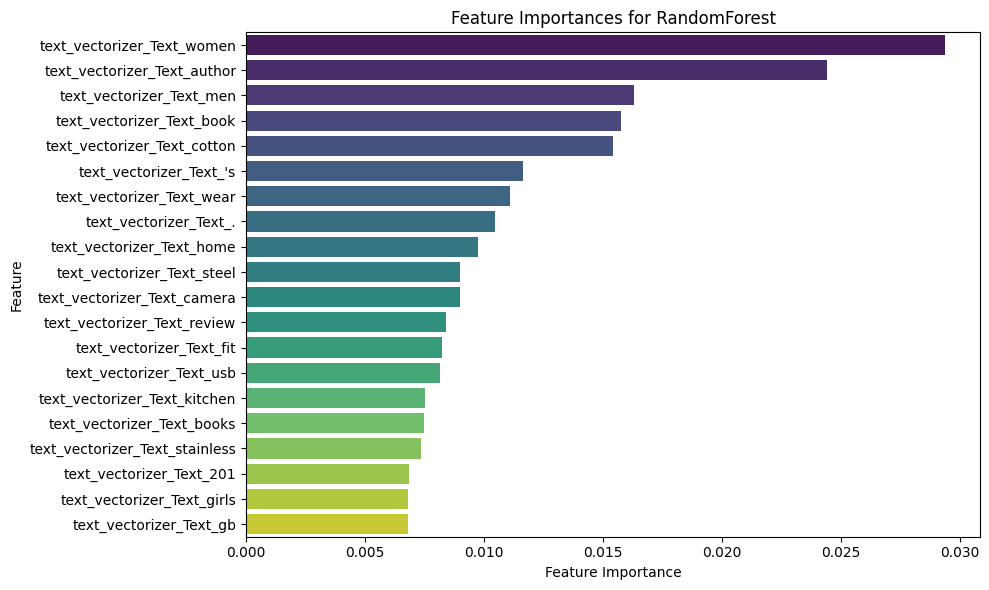

<Figure size 1500x600 with 0 Axes>

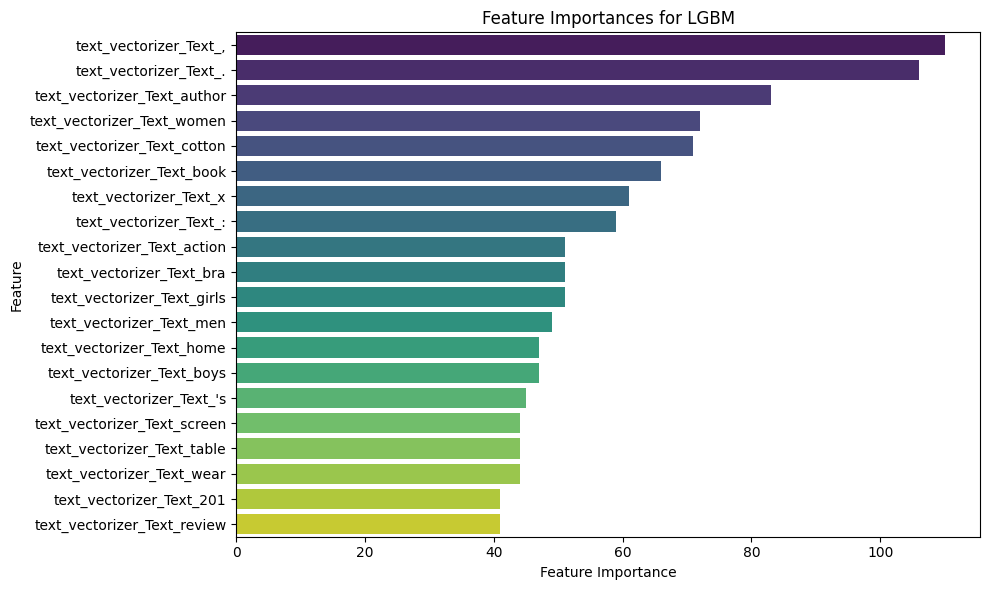

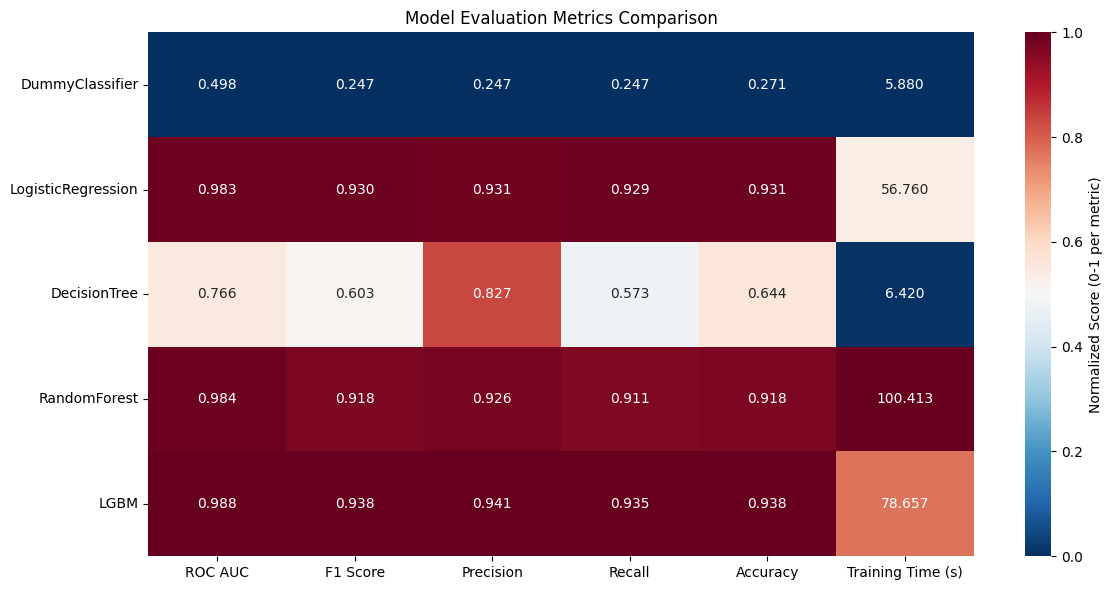

In [ ]:
count_vecotrizer_cleaned_metrics = train_evaluate_models_cv(
    models, X_cleaned, y, count_vectorizer_processor, cv, SEED
)

In [ ]:
metrics_file_name = "count_vecotrizer_cleaned_metrics"

In [ ]:
save_metrics_to_csv(count_vecotrizer_cleaned_metrics, metrics_file_name)

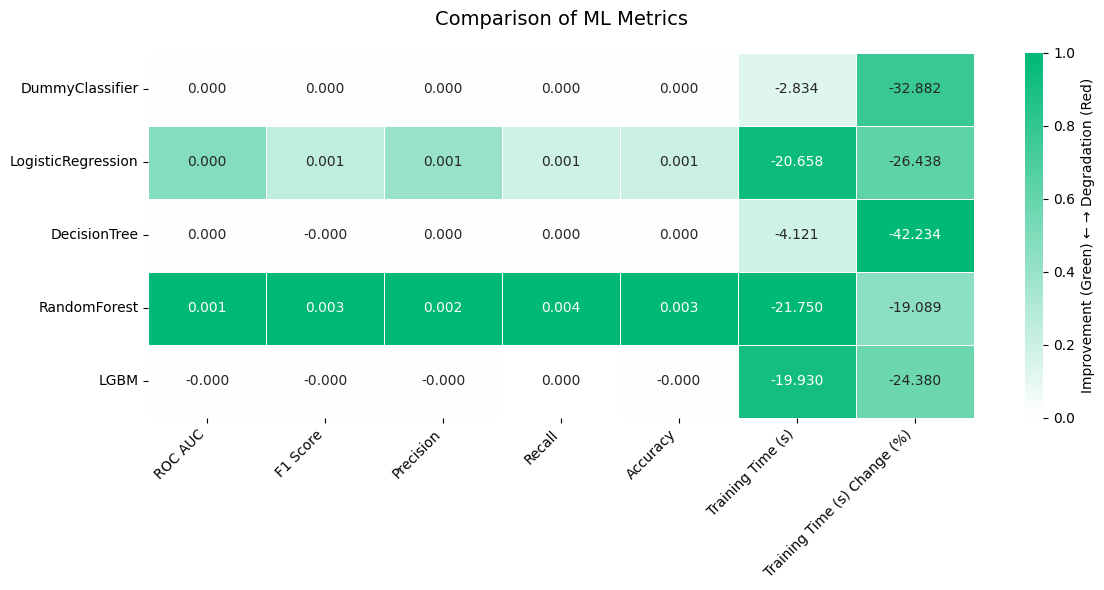

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,-2.834179,-32.882402
LogisticRegression,4.996922e-04,8.237901e-04,0.000873,0.000785,6.833045e-04,-20.658063,-26.437703
DecisionTree,3.317677e-07,-2.126900e-07,0.000002,0.000000,3.881089e-09,-4.121275,-42.234343
RandomForest,1.043196e-03,3.380787e-03,0.002163,0.004121,3.309156e-03,-21.749887,-19.089459
LGBM,-2.186699e-05,-1.433826e-04,-0.000327,0.000017,-3.596605e-05,-19.929612,-24.380410


In [ ]:
compare_metrics_heatmap(
    count_vectorizer_metrics.to_dataframe(),
    count_vecotrizer_cleaned_metrics.to_dataframe(),
)

Изменение метрик незначительно, однако наблюдается прирост в скорости обучения, что делает данное преобразование целесообразным

#### 2.1.3 Удалим пунктуацию и стоп-слова

In [ ]:
X_punc_cleaned = X.copy()
X_punc_cleaned["Text"] = X_punc_cleaned["Text"].map(
    lambda tokens: filter_tokens(
        tokens,
        remove_stopwords=True,
        remove_punctuation_tokens=True,
        lowercase_for_counting=True,
    )
)

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

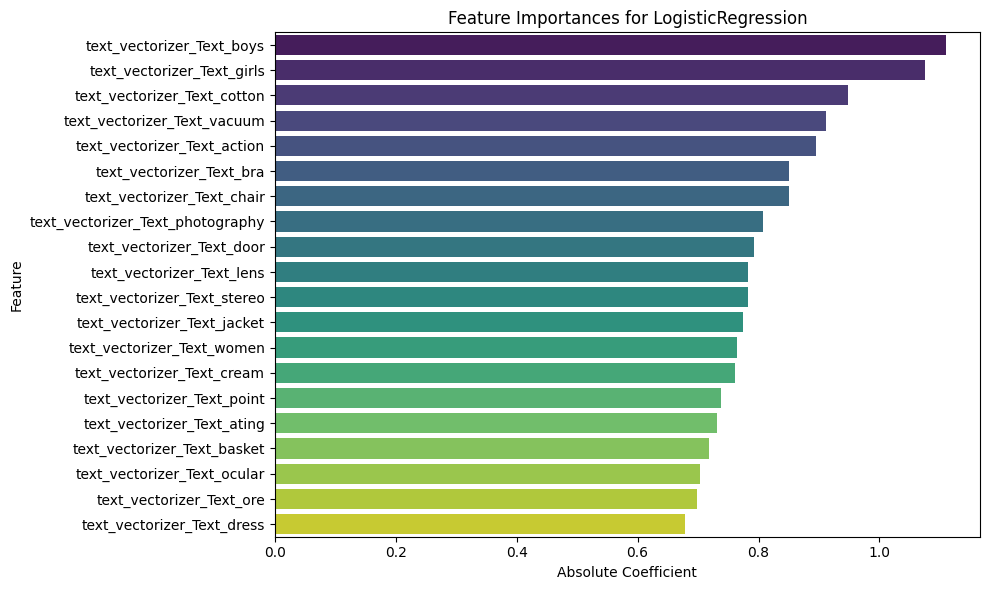

<Figure size 1500x600 with 0 Axes>

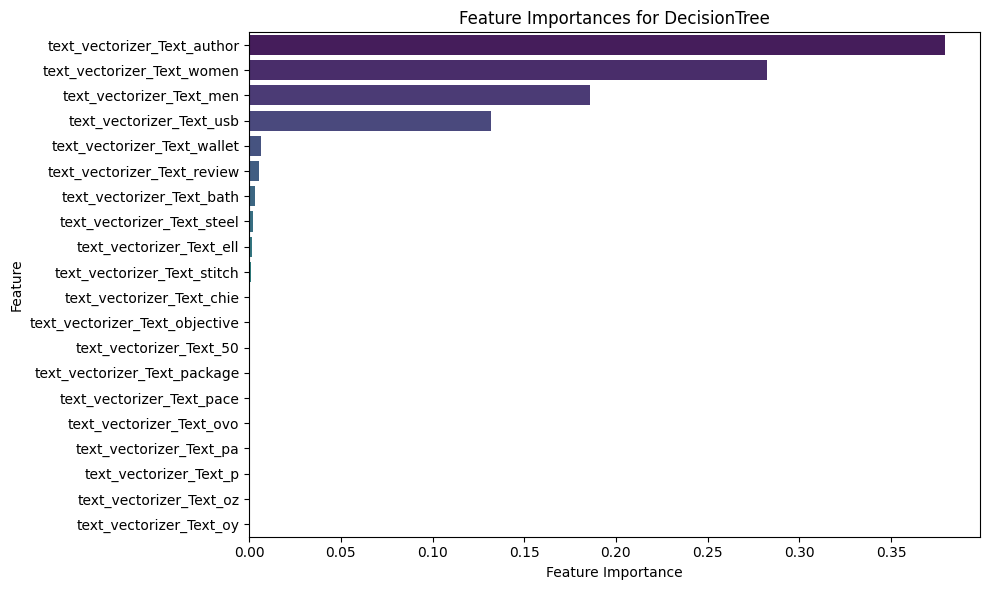

<Figure size 1500x600 with 0 Axes>

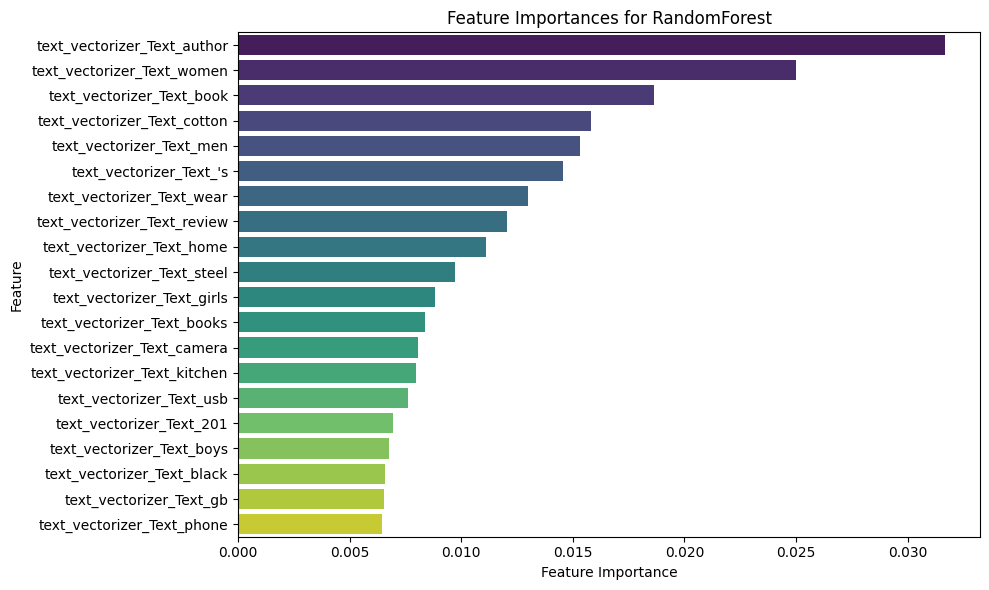

<Figure size 1500x600 with 0 Axes>

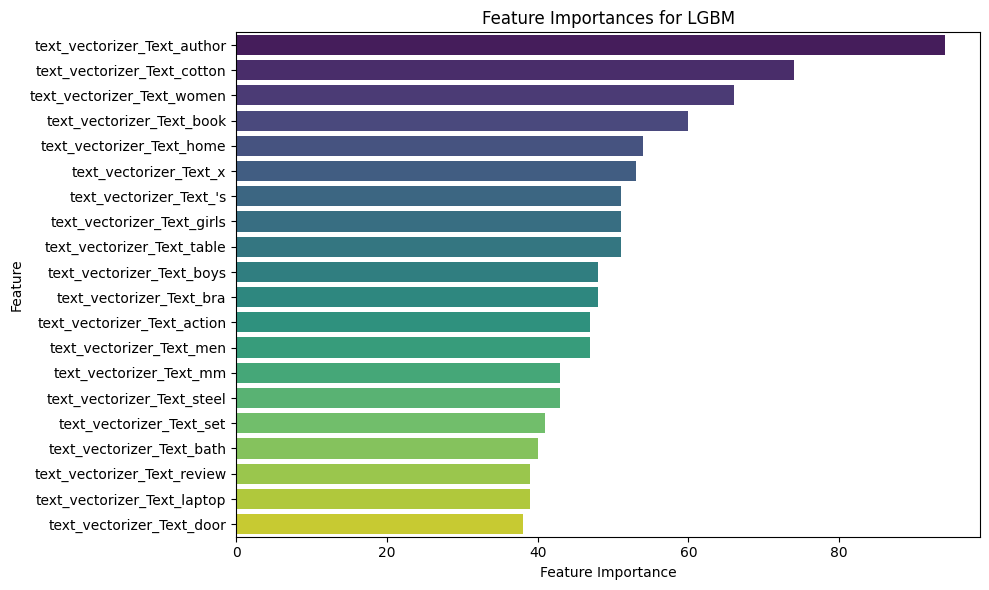

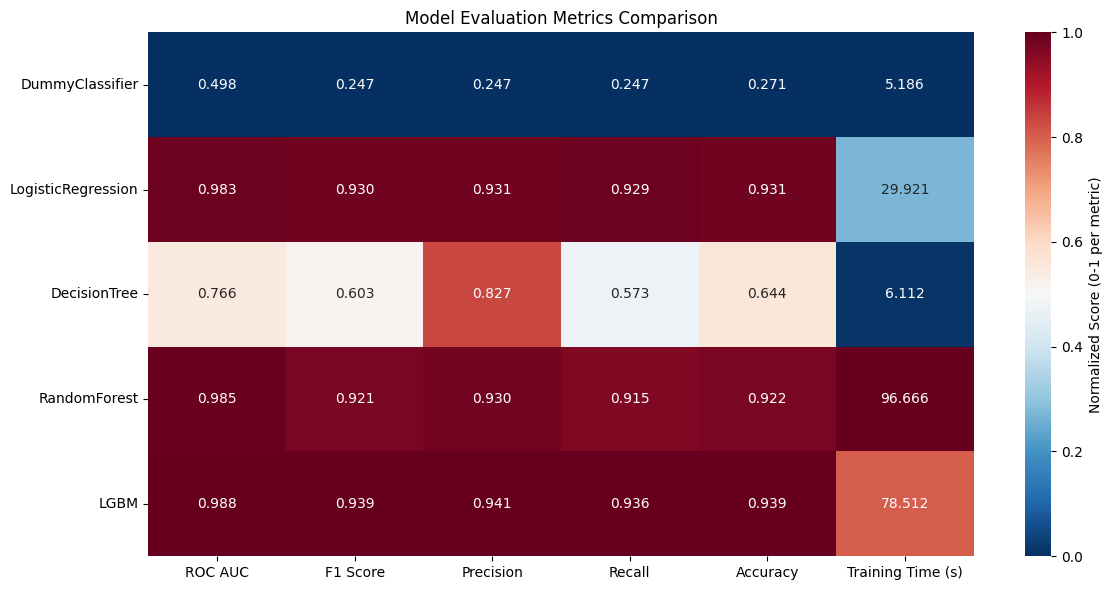

In [ ]:
count_vecotrizer_punc_cleaned_metrics = train_evaluate_models_cv(
    models, X_punc_cleaned, y, count_vectorizer_processor, cv, SEED
)

In [ ]:
metrics_file_name = "count_vecotrizer_punc_cleaned_metrics"

In [ ]:
# save_metrics_to_json(count_vecotrizer_punc_cleaned_metrics, metrics_file_name)

In [ ]:
count_vecotrizer_punc_cleaned_metrics = load_metrics_from_json(metrics_file_name)

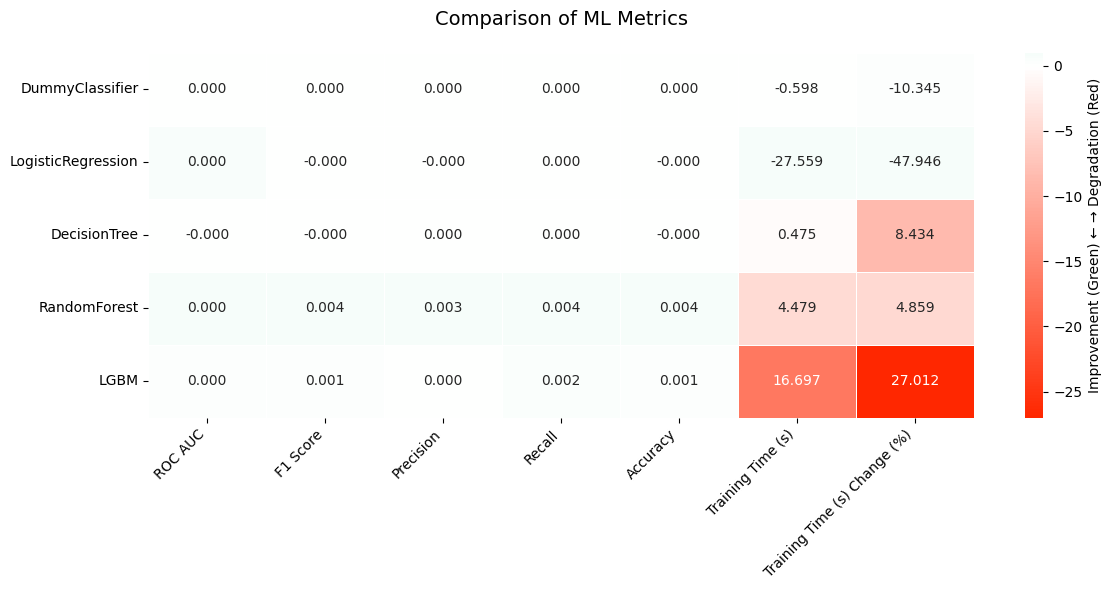

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-0.598475,-10.345374
LogisticRegression,0.000272,-0.000006,-0.000132,1.494742e-04,-3.598933e-05,-27.559397,-47.945576
DecisionTree,-0.000014,-0.000003,0.000021,1.916013e-08,-3.881089e-09,0.475421,8.434182
RandomForest,0.000481,0.003600,0.003245,3.776603e-03,3.740686e-03,4.479204,4.858837
LGBM,0.000116,0.000840,0.000095,1.517459e-03,8.632434e-04,16.697254,27.011761


In [ ]:
compare_metrics_heatmap(
    count_vecotrizer_cleaned_metrics.to_dataframe(),
    count_vecotrizer_punc_cleaned_metrics.to_dataframe(),
)

Изменений в качестве нет. Уменьшилось время обучения логистической регрессии. У LGBM время обучения стало больше

#### 2.1.4 Топ 100 важных токенов

In [ ]:
count_vectorizer_important_tokens_preprocessor = Pipeline(
    [
        (
            "columns",
            ColumnTransformer(
                [
                    (
                        "text_pipeline",
                        Pipeline(
                            [
                                ("token_selector", NgramFeatureSelector(top_k=100)),
                                (
                                    "vectorizer",
                                    CountVectorizer(
                                        analyzer=lambda x: x,
                                        min_df=50,
                                        dtype=np.float32,
                                    ),
                                ),
                            ]
                        ),
                        "Text",
                    ),
                ],
                remainder="passthrough",
                verbose_feature_names_out=True,
            ),
        )
    ]
)

count_vectorizer_important_tokens_preprocessor

Pipeline(steps=[('columns',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('text_pipeline',
                                                  Pipeline(steps=[('token_selector',
                                                                   NgramFeatureSelector()),
                                                                  ('vectorizer',
                                                                   CountVectorizer(analyzer=<function <lambda> at 0x7f0b370493a0>,
                                                                                   dtype=<class 'numpy.float32'>,
                                                                                   min_df=50))]),
                                                  'Text')]))])

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

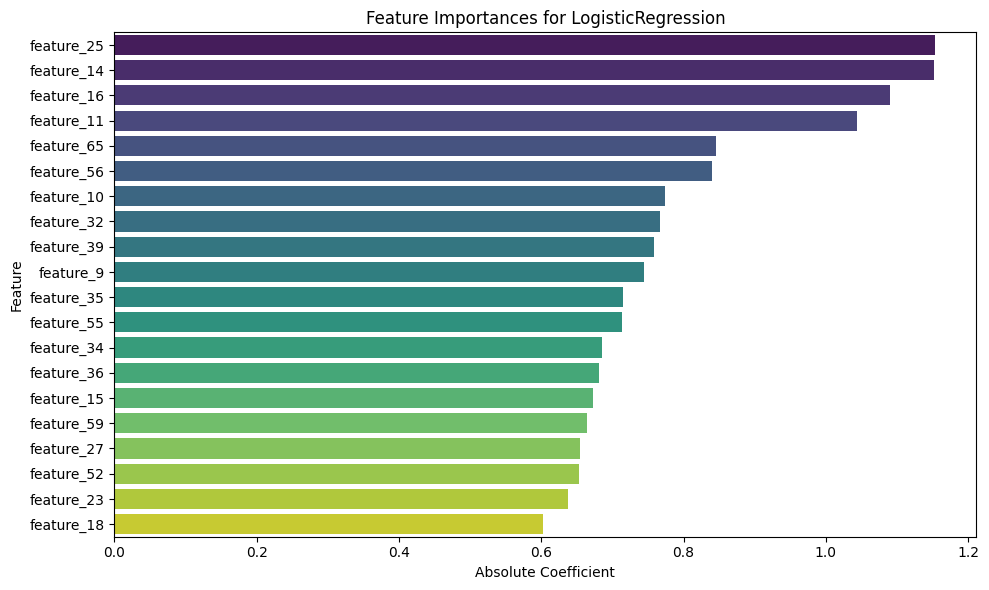

<Figure size 1500x600 with 0 Axes>

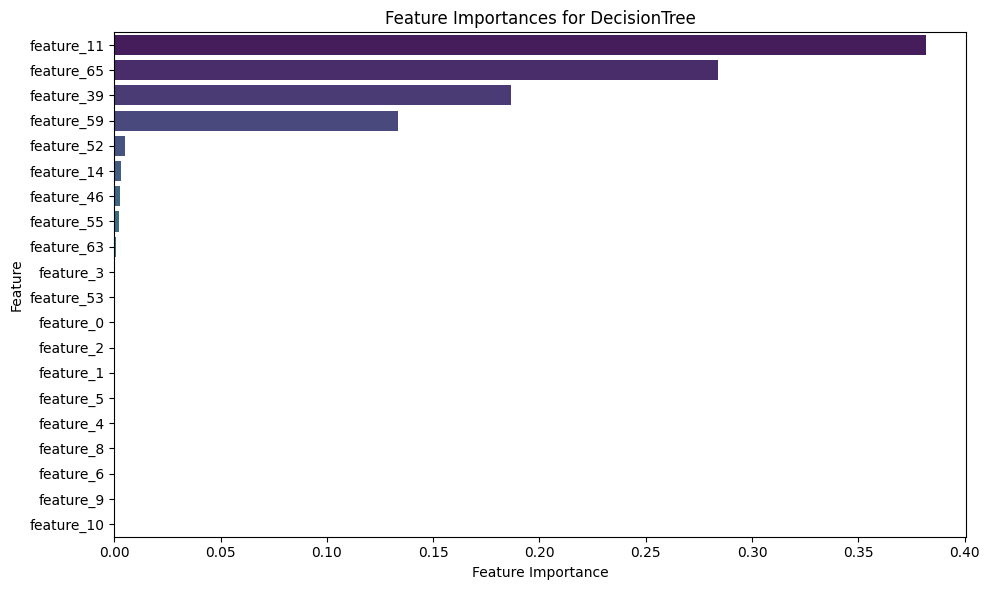

<Figure size 1500x600 with 0 Axes>

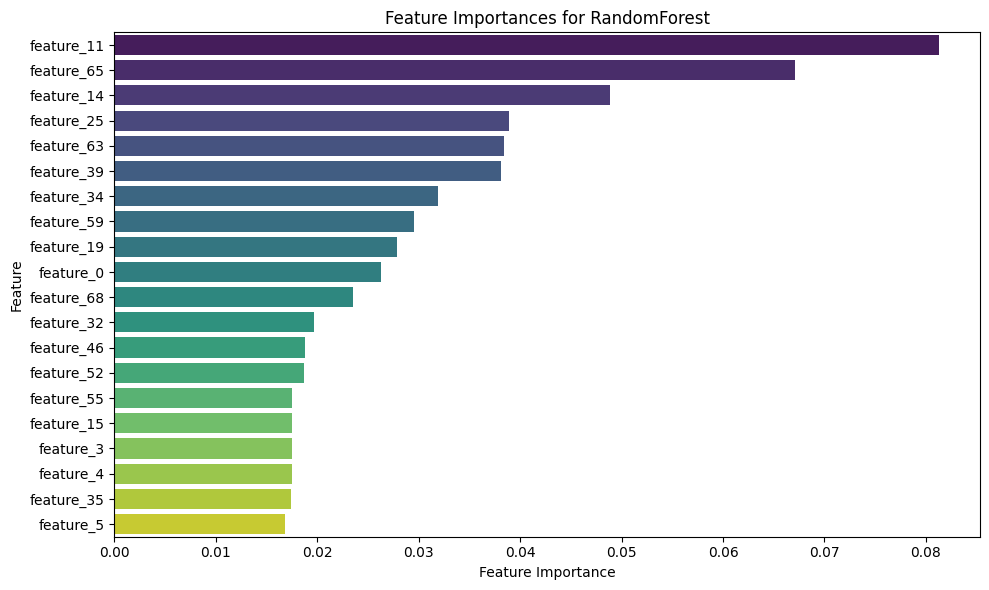

<Figure size 1500x600 with 0 Axes>

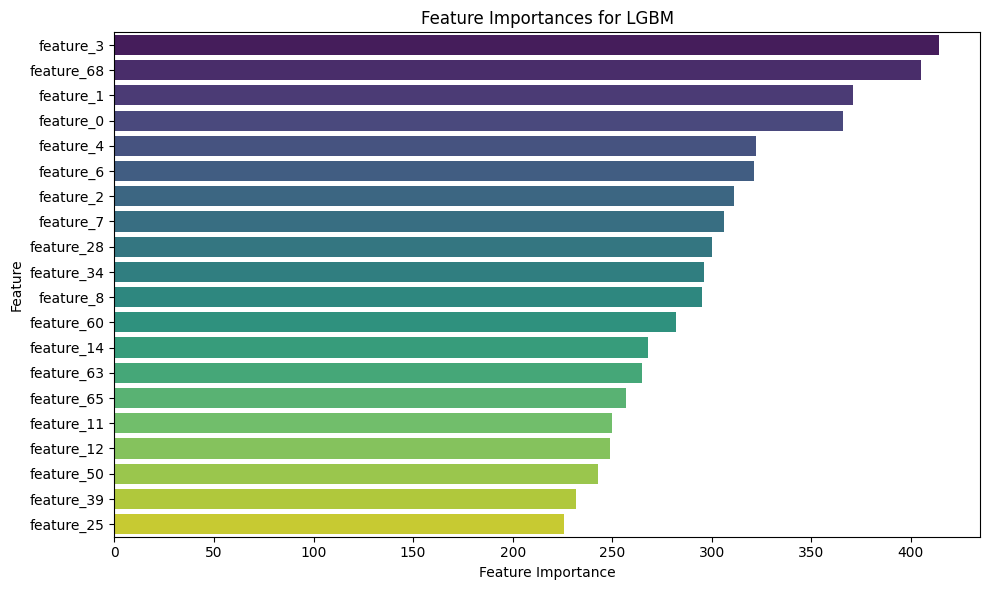

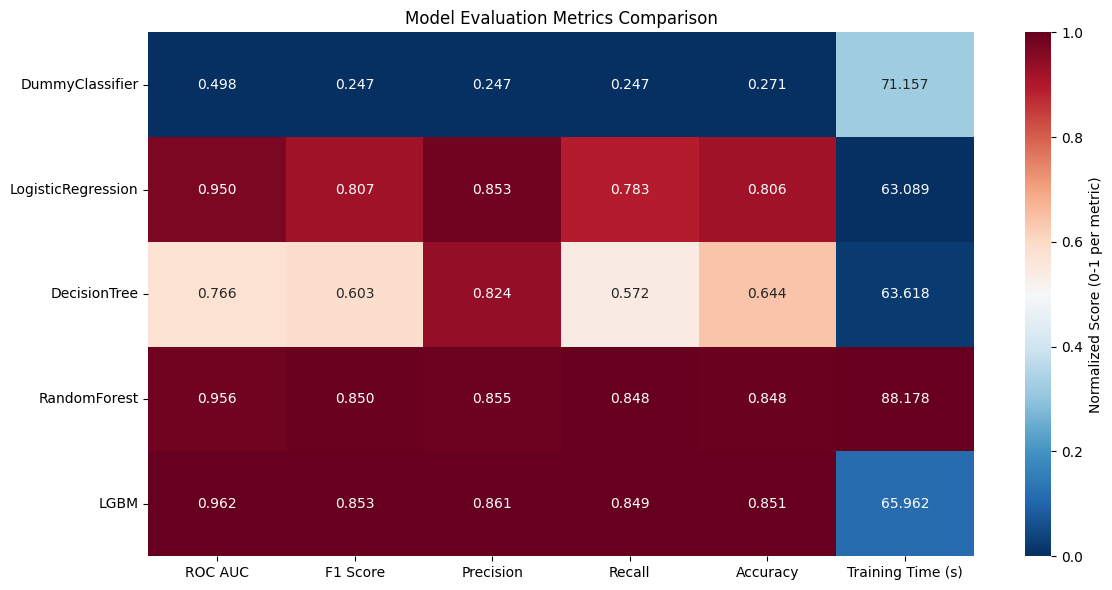

In [ ]:
count_vectorizer_important_tokens_metrics = train_evaluate_models_cv(
    models, X_cleaned, y, count_vectorizer_important_tokens_preprocessor, cv, SEED
)

In [ ]:
metrics_file_name = "count_vectorizer_important_tokens_metrics"

In [ ]:
save_metrics_to_csv(count_vectorizer_important_tokens_metrics, metrics_file_name)

In [ ]:
# count_vectorizer_important_tokens_metrics = load_metrics_from_csv(metrics_file_name)

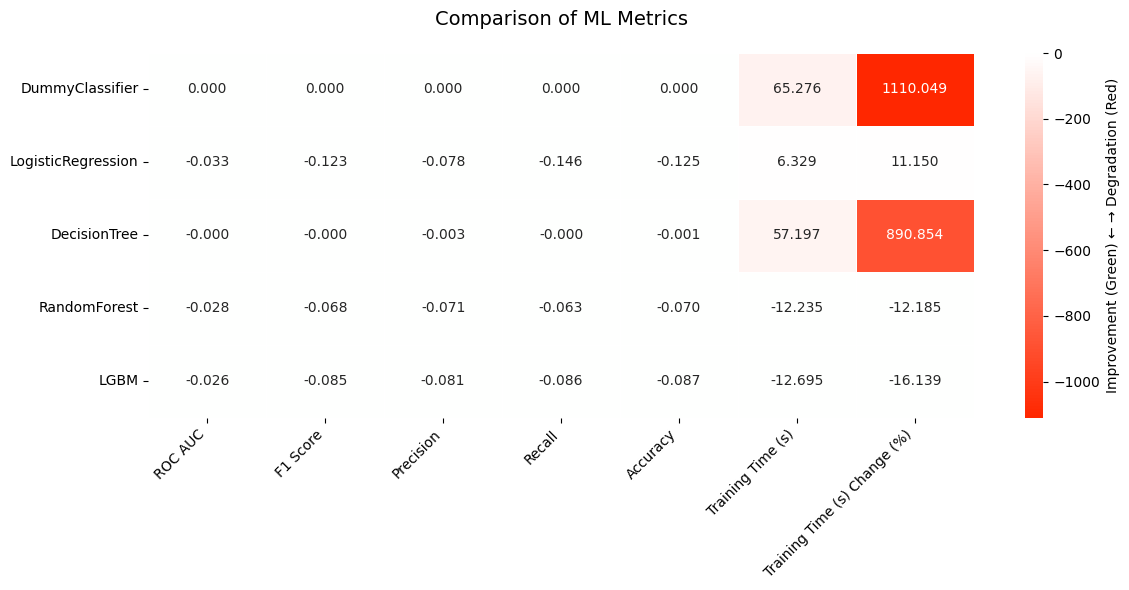

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,0.000000,0.000000,0.000000,0.000000,0.000000,65.276132,1110.049427
LogisticRegression,-0.033101,-0.122745,-0.077721,-0.146258,-0.124775,6.328522,11.149618
DecisionTree,-0.000115,-0.000328,-0.002946,-0.000388,-0.000683,57.197155,890.853722
RandomForest,-0.028222,-0.067691,-0.070921,-0.063185,-0.069527,-12.235284,-12.184957
LGBM,-0.025952,-0.084820,-0.080748,-0.086111,-0.087080,-12.694880,-16.139466


In [ ]:
compare_metrics_heatmap(
    count_vecotrizer_cleaned_metrics.to_dataframe(),
    count_vectorizer_important_tokens_metrics.to_dataframe(),
)

Метрики ухудшились прктически у всех моделей. Видимо модели способны сами выбрать для себя наиболее важные токены.

Время обучения выросло у линейной регрессии. У случайного леса и LGBM время обучения уменьшилось

### 2.2. TfidfVectorizer

#### 2.2.1 Без очистки токенов

In [ ]:
tfidf_vectorizer_preprocessor = Pipeline(
    [
        (
            "vectorizer",
            ColumnTransformer(
                [
                    (
                        "text_vectorizer",
                        TfidfVectorizer(
                            analyzer=lambda x: x, min_df=50, dtype=np.float32
                        ),
                        "Text",
                    )
                ],
                remainder="passthrough",
                verbose_feature_names_out=True,
            ),
        )
    ]
)

tfidf_vectorizer_preprocessor

Pipeline(steps=[('vectorizer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('text_vectorizer',
                                                  TfidfVectorizer(analyzer=<function <lambda> at 0x7f0b2fcc2020>,
                                                                  dtype=<class 'numpy.float32'>,
                                                                  min_df=50),
                                                  'Text')]))])

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

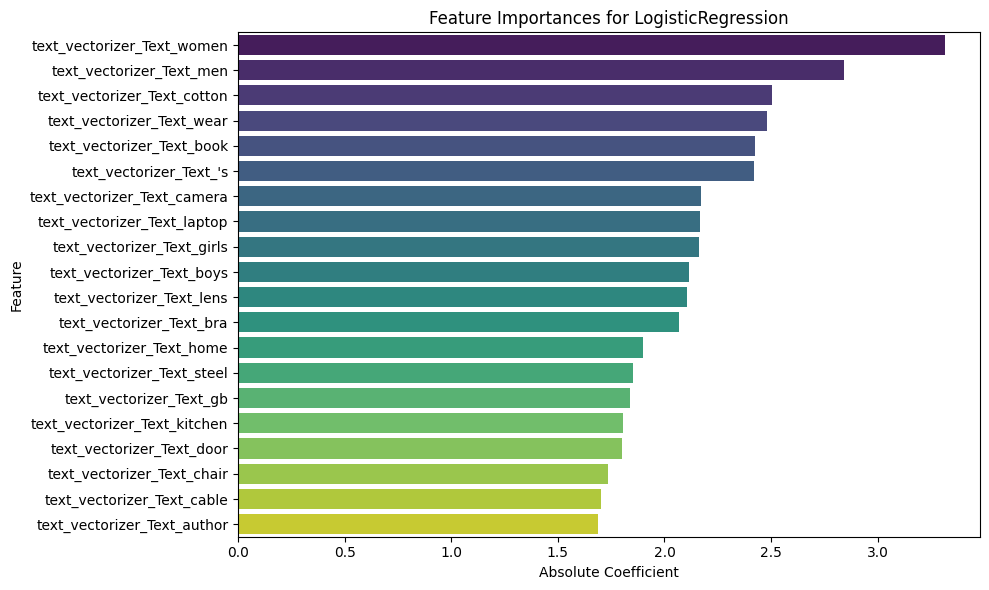

<Figure size 1500x600 with 0 Axes>

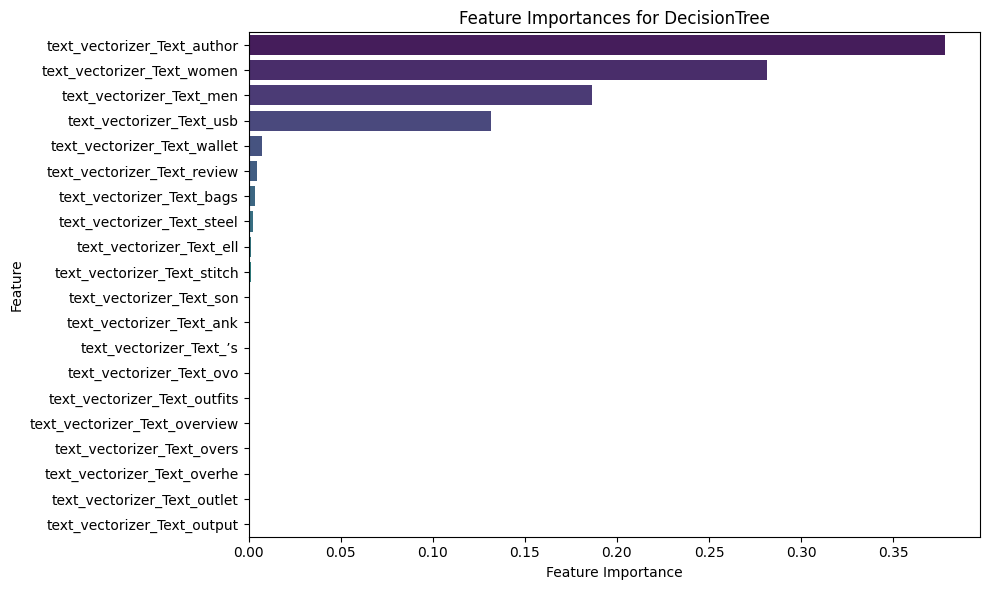

<Figure size 1500x600 with 0 Axes>

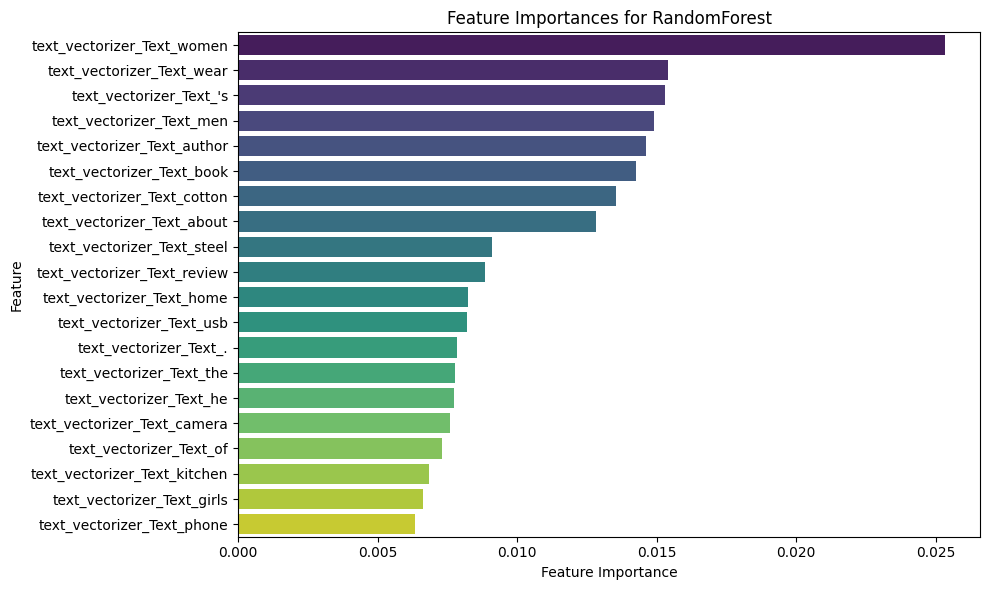

<Figure size 1500x600 with 0 Axes>

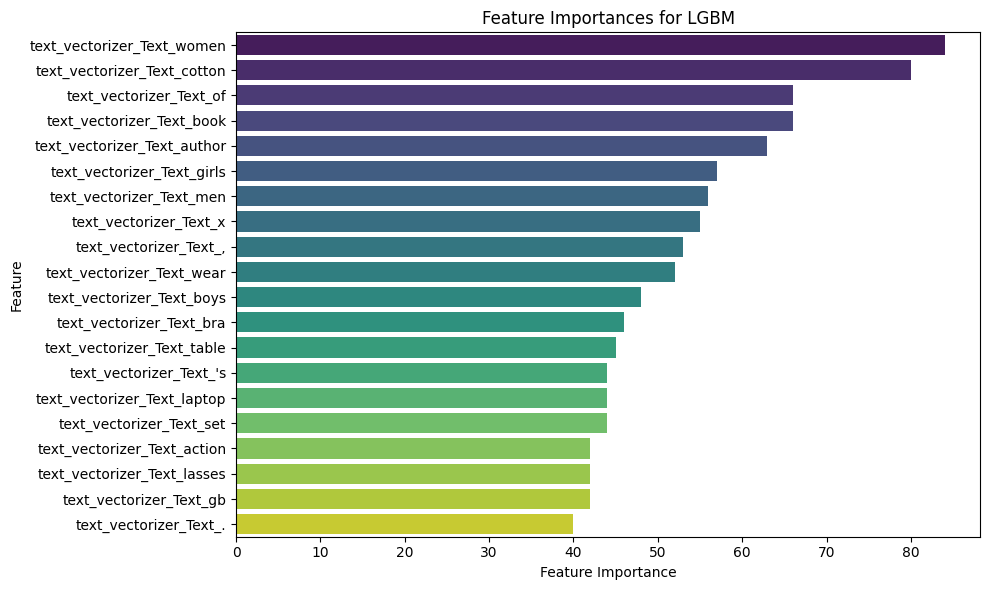

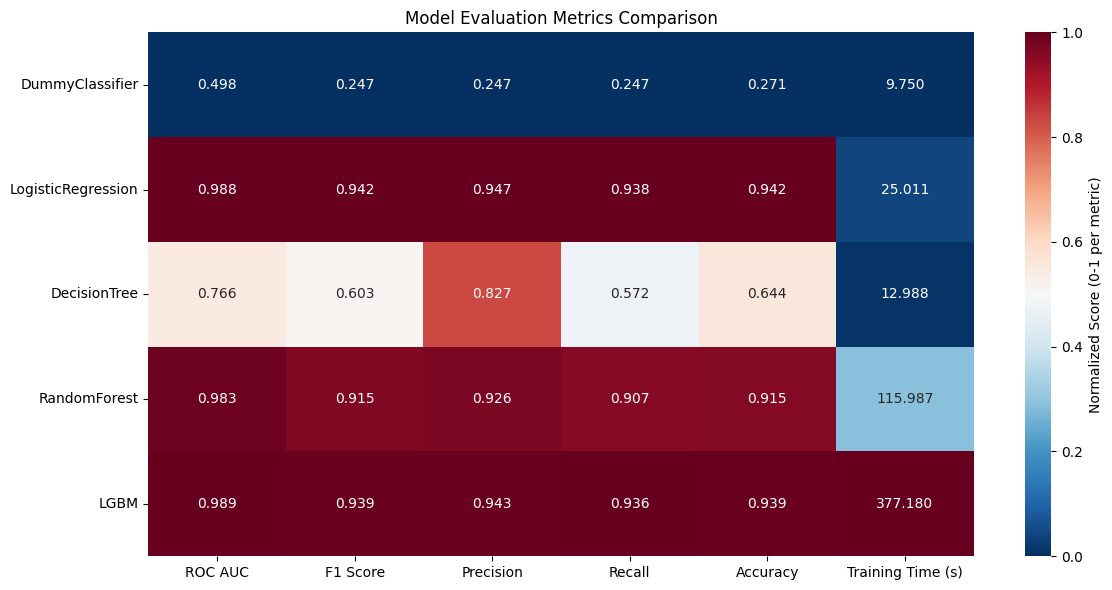

In [ ]:
tfidf_vectorizer_metrics = train_evaluate_models_cv(
    models, X, y, tfidf_vectorizer_preprocessor, cv, SEED
)

In [ ]:
metrics_file_name = "tfidf_vectorizer_metrics"

save_metrics_to_csv(tfidf_vectorizer_metrics, metrics_file_name)
# tfidf_vectorizer_metrics = load_metrics_from_csv(metrics_file_name)

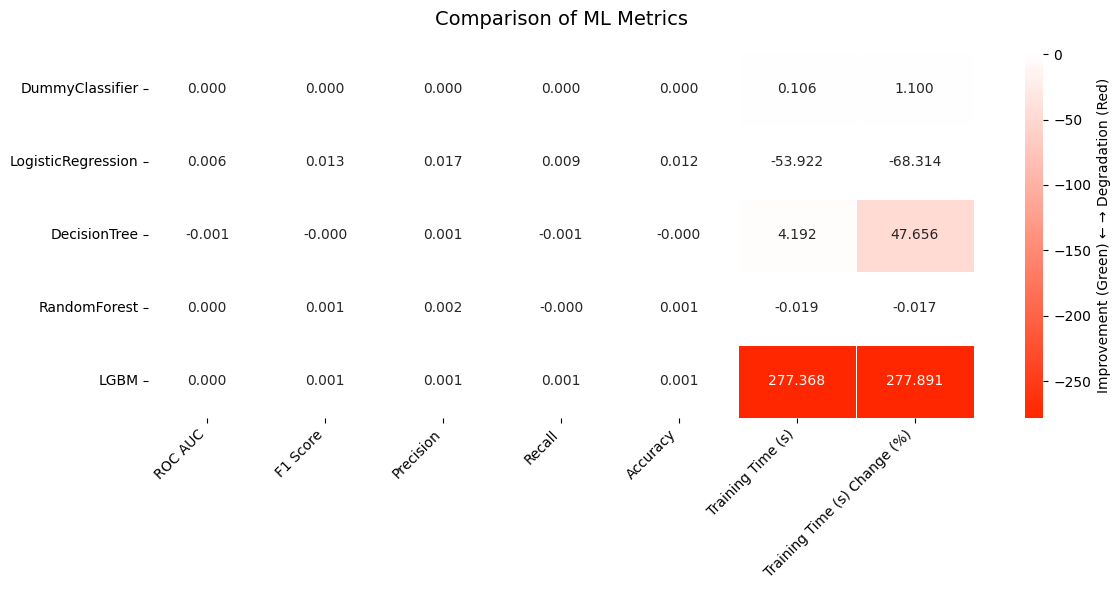

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,0.000000,0.000000,0.000000,0.000000,0.000000,0.106115,1.100333
LogisticRegression,0.005778,0.012974,0.016849,0.009452,0.012409,-53.922198,-68.313638
DecisionTree,-0.000604,-0.000322,0.000652,-0.000542,-0.000072,4.191754,47.655901
RandomForest,0.000174,0.000876,0.002172,-0.000025,0.000863,-0.019429,-0.016749
LGBM,0.000350,0.001205,0.000988,0.001370,0.001367,277.368259,277.890823


In [ ]:
compare_metrics_heatmap(
    count_vectorizer_metrics.to_dataframe(), tfidf_vectorizer_metrics.to_dataframe()
)

Метрики практически не изменились

Время обучения выросло очень сильно у LGBM. У логистической регрессии время обучения значительно снизилось

#### 2.2.2 Удаление стоп-слов

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

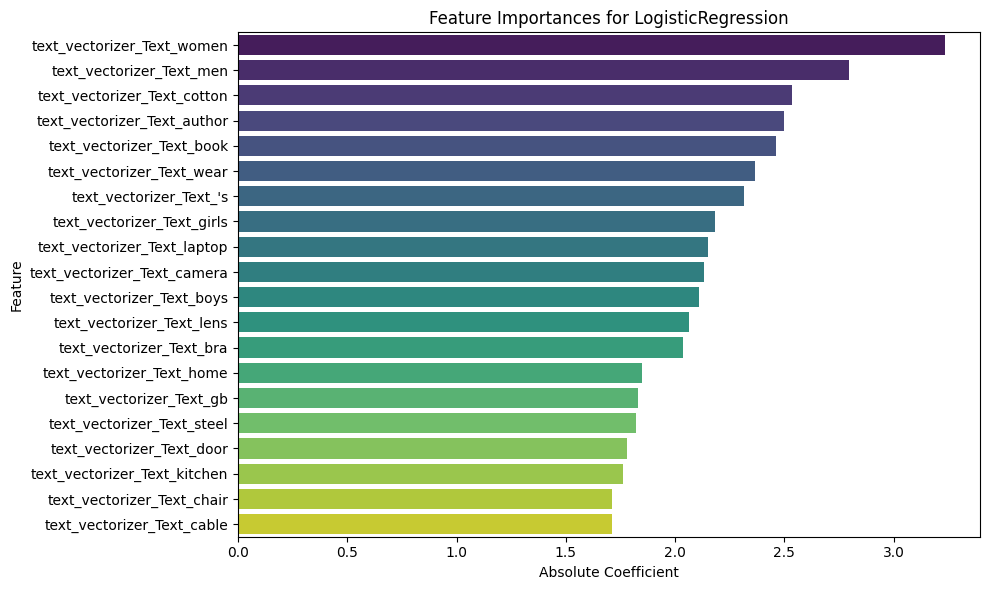

<Figure size 1500x600 with 0 Axes>

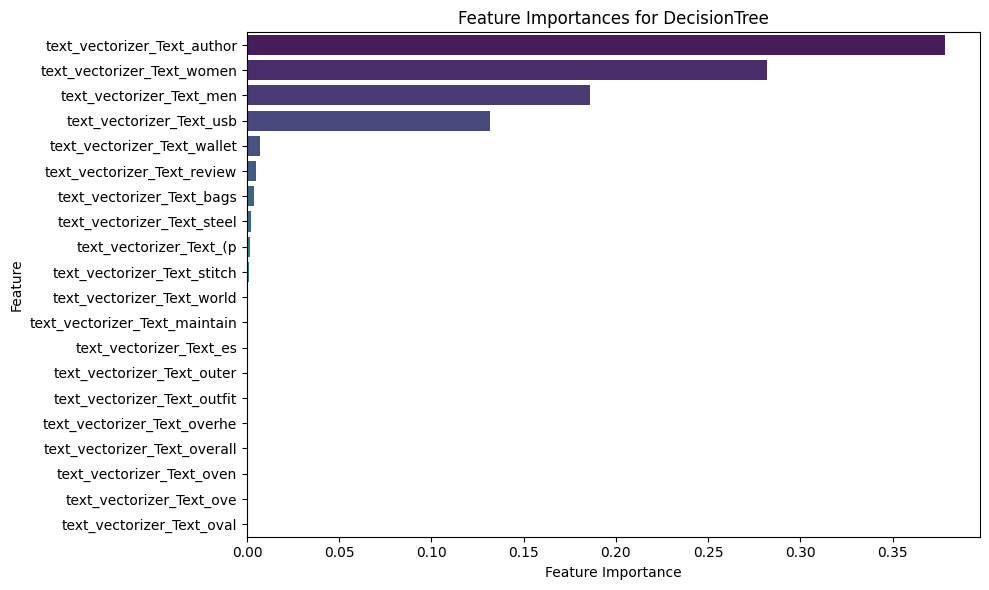

<Figure size 1500x600 with 0 Axes>

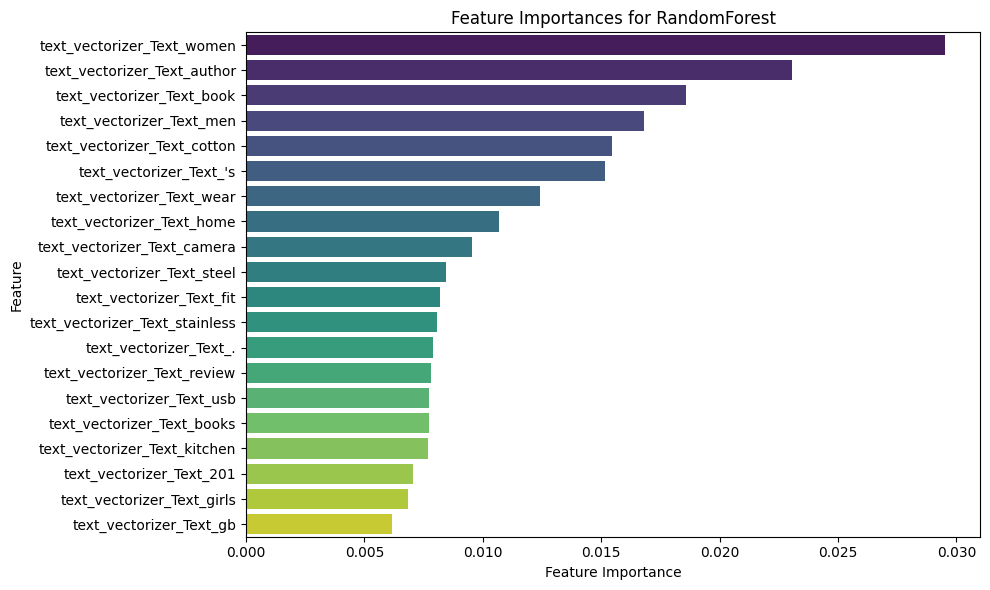

<Figure size 1500x600 with 0 Axes>

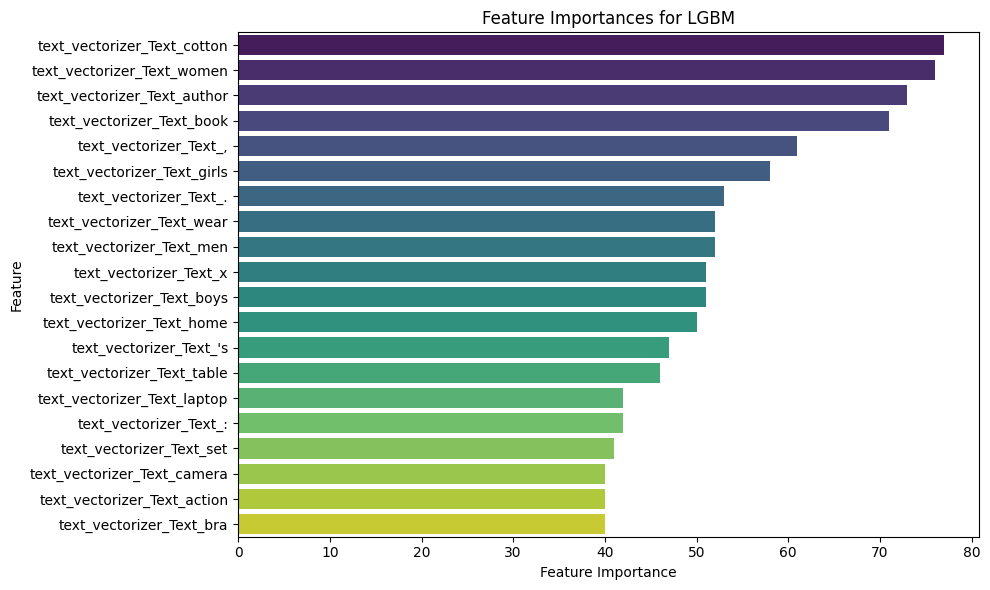

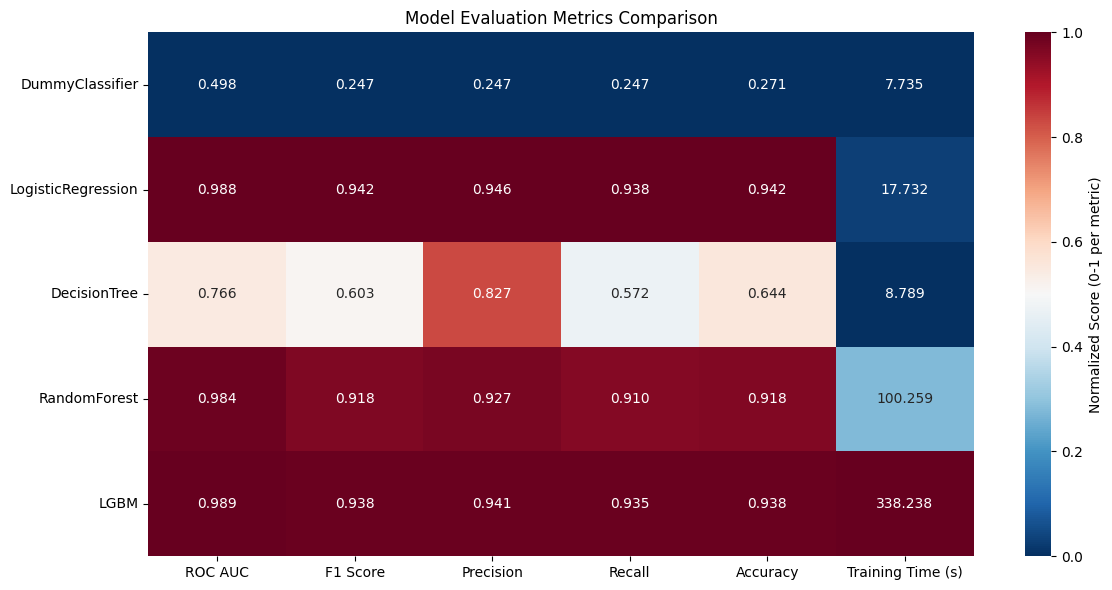

In [ ]:
tfidf_vectorizer_cleaned_metrics = train_evaluate_models_cv(
    models, X_cleaned, y, tfidf_vectorizer_preprocessor, cv, SEED
)

In [ ]:
metrics_file_name = "tfidf_vectorizer_cleaned_metrics"

save_metrics_to_csv(tfidf_vectorizer_cleaned_metrics, metrics_file_name)
# tfidf_vectorizer_cleaned_metrics = load_metrics_from_csv(metrics_file_name)

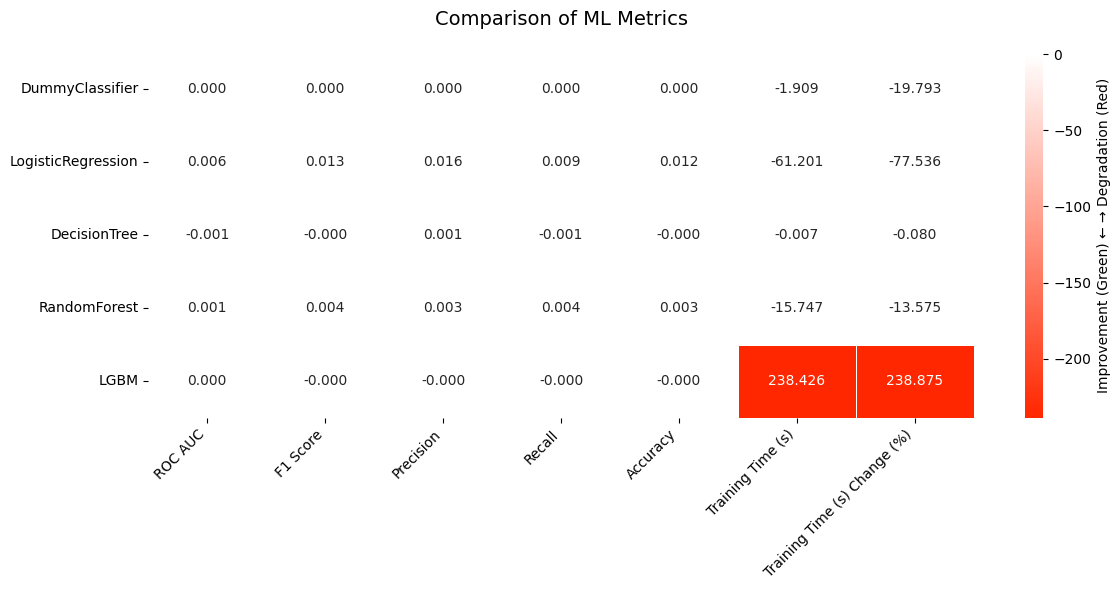

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,0.000000,0.000000,0.000000,0.000000,0.000000,-1.908787,-19.792638
LogisticRegression,0.006113,0.012708,0.016310,0.009397,0.012193,-61.201409,-77.535618
DecisionTree,-0.000571,-0.000386,0.000701,-0.000570,-0.000108,-0.007062,-0.080284
RandomForest,0.001230,0.003531,0.003268,0.003605,0.003381,-15.747362,-13.574532
LGBM,0.000355,-0.000259,-0.000469,-0.000112,-0.000144,238.425576,238.874772


In [ ]:
compare_metrics_heatmap(
    count_vectorizer_metrics.to_dataframe(),
    tfidf_vectorizer_cleaned_metrics.to_dataframe(),
)

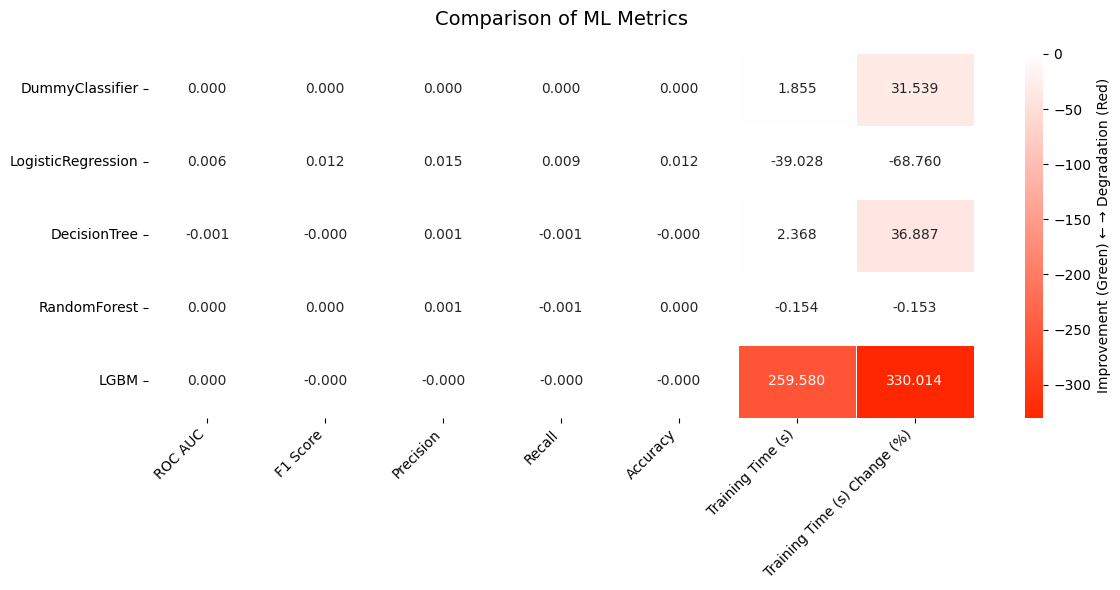

,ROC AUC,F1 Score,Precision,Recall,Accuracy,Training Time (s),Training Time (s) Change (%)
DummyClassifier,0.000000,0.000000,0.000000,0.000000,0.000000,1.854668,31.539442
LogisticRegression,0.005613,0.011884,0.015437,0.008612,0.011510,-39.028121,-68.759909
DecisionTree,-0.000572,-0.000386,0.000699,-0.000570,-0.000108,2.368326,36.887005
RandomForest,0.000187,0.000150,0.001105,-0.000515,0.000072,-0.153723,-0.153091
LGBM,0.000377,-0.000116,-0.000142,-0.000129,-0.000108,259.580154,330.013750


In [ ]:
compare_metrics_heatmap(
    count_vecotrizer_cleaned_metrics.to_dataframe(),
    tfidf_vectorizer_cleaned_metrics.to_dataframe(),
)

Удаление стоп-слов не принесло улучшений для TF-IDF что объяснимо тем, что данный алгоритм самостоятельно понижает важность подобных токенов.

Время обучения выросло очень сильно у LGBM. У логистической регрессии время обучения снизилось

## Выводы

Лучший результат показала комбинация `TfidfVectorizer` и `LogisticRegression`/`LGBM` с удалением стоп-слов.

Для дальнейшего сравнения с нейросетями будет выбран подход `TfidfVectorizer` + `LogisticRegression` с удалением стоп-слов, так как он гораздо быстрее работает и не уступает по метрикам LGBM